# IntelliPulse V7.1 — Baseline Data Profile
---

**Objective:** Establish a reusable baseline profile representing the statistical
characteristics of the **original training data**. This profile will later be used
to detect data drift in incoming batches.

**Scope:**
- Profile is built from `X_train` only (5,634 rows).
- The target column (`Churn`) is **excluded** from drift monitoring.
- The tuned XGBoost model (V4) and threshold (V5 = 0.29) are **not modified**.
- No drift is calculated yet — this is purely the reference profile.

---
## 1. Identify Existing Data Pipeline

We reuse the identical data loading, cleaning, and splitting logic from V1–V6.

| Component | Detail |
|---|---|
| Dataset | `data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv` |
| Target | `Churn` → mapped to 0/1 |
| ID Column | `customerID` (dropped before modelling) |
| TotalCharges Fix | `pd.to_numeric(errors='coerce').fillna(0.0)` |
| Train/Test Split | 80/20, `random_state=42`, `stratify=y` |
| Preprocessing | Numerical: median impute → standard scale; Categorical: mode impute → one-hot encode |
| Feature Definitions | `artifacts/metrics/feature_definitions_v1.json` |

**Monitoring baseline dataset:** The **training split** (`X_train`, 5,634 rows).

In [1]:
import os
import json
from pathlib import Path
from datetime import datetime

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

# ── Configuration ────────────────────────────────────────────────────
RANDOM_STATE = 42

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})

PROJECT_ROOT = Path.cwd().parent
RAW_DATA_PATH = PROJECT_ROOT / "data" / "raw" / "WA_Fn-UseC_-Telco-Customer-Churn.csv"
METRICS_DIR = PROJECT_ROOT / "artifacts" / "metrics"
MONITORING_DIR = PROJECT_ROOT / "artifacts" / "monitoring"

# Create monitoring directory (new for V7)
MONITORING_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root       : {PROJECT_ROOT}")
print(f"Raw data path      : {RAW_DATA_PATH}")
print(f"Monitoring dir     : {MONITORING_DIR}")
print(f"Random state       : {RANDOM_STATE}")

Project root       : /Users/shubhamswaraj/Desktop/PLACEMENT/IntelliPulse
Raw data path      : /Users/shubhamswaraj/Desktop/PLACEMENT/IntelliPulse/data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv
Monitoring dir     : /Users/shubhamswaraj/Desktop/PLACEMENT/IntelliPulse/artifacts/monitoring
Random state       : 42


In [2]:
# ── Load raw data (identical to V1-V6) ────────────────────────────────
assert RAW_DATA_PATH.exists(), f"Dataset not found at {RAW_DATA_PATH}"
df = pd.read_csv(RAW_DATA_PATH)

# Fix TotalCharges (identical to V1-V6)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce").fillna(0.0)

ID_COL = "customerID"
TARGET_COL = "Churn"

# ── Load feature definitions from V1 (avoid hard-coding) ─────────────
feat_def_path = METRICS_DIR / "feature_definitions_v1.json"
with open(feat_def_path) as f:
    feature_defs = json.load(f)

NUMERICAL_FEATURES = feature_defs["numerical_features"]
CATEGORICAL_FEATURES = feature_defs["categorical_features"]

print(f"Loaded feature definitions from: {feat_def_path}")
print(f"  Numerical features  ({len(NUMERICAL_FEATURES)}): {NUMERICAL_FEATURES}")
print(f"  Categorical features ({len(CATEGORICAL_FEATURES)}): {CATEGORICAL_FEATURES}")
print(f"  Target column       : {feature_defs['target_column']}")
print(f"  ID column           : {feature_defs['id_column']}")

Loaded feature definitions from: /Users/shubhamswaraj/Desktop/PLACEMENT/IntelliPulse/artifacts/metrics/feature_definitions_v1.json
  Numerical features  (4): ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']
  Categorical features (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
  Target column       : Churn
  ID column           : customerID


In [3]:
# ── Prepare X and y (identical to V1-V6) ──────────────────────────────
X = df.drop(columns=[ID_COL, TARGET_COL])
y = df[TARGET_COL].map({"No": 0, "Yes": 1}).astype(int)

# ── Train/Test Split (identical to V1-V6) ─────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Full dataset   : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Training set   : {X_train.shape[0]:,} rows × {X_train.shape[1]} columns")
print(f"Test set       : {X_test.shape[0]:,} rows × {X_test.shape[1]} columns")
print()
print("=" * 60)
print("  BASELINE DATASET = X_train (training split only)")
print(f"  Rows: {X_train.shape[0]:,}   Features: {X_train.shape[1]}")
print("=" * 60)

Full dataset   : 7,043 rows × 21 columns
Training set   : 5,634 rows × 19 columns
Test set       : 1,409 rows × 19 columns

  BASELINE DATASET = X_train (training split only)
  Rows: 5,634   Features: 19


---
## 2. Baseline Dataset

The baseline is the **original training data (`X_train`)** before model prediction.

It represents the feature distribution the model was trained on.

### Why is the target column excluded from drift monitoring?

> **Drift monitoring asks whether the *input* distribution has changed.**
> The target/outcome (`Churn`) is not an input feature — it is what the model predicts.
> Target drift (also called concept drift or label drift) is handled separately
> during **model performance monitoring**, where we compare predicted vs actual outcomes.
> Feature drift monitoring focuses exclusively on whether the characteristics of
> incoming data (the X variables) have shifted relative to the training distribution.

In [4]:
# ── Confirm target is excluded ─────────────────────────────────────────
baseline_df = X_train.copy()
monitored_features = list(baseline_df.columns)

assert TARGET_COL not in monitored_features, "Target column must NOT be in monitored features!"
assert ID_COL not in monitored_features, "ID column must NOT be in monitored features!"

print(f"Baseline shape: {baseline_df.shape}")
print(f"Monitored features ({len(monitored_features)}): {monitored_features}")
print()
print(f"Target column '{TARGET_COL}' excluded: ✓")
print(f"ID column '{ID_COL}' excluded: ✓")

Baseline shape: (5634, 19)
Monitored features (19): ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']

Target column 'Churn' excluded: ✓
ID column 'customerID' excluded: ✓


---
## 3. Identify Feature Types

Feature types are derived from `feature_definitions_v1.json` (established in V1).
We validate that all defined features are actually present in the baseline dataset.

In [5]:
# ── Validate feature presence ──────────────────────────────────────────
num_present = [f for f in NUMERICAL_FEATURES if f in baseline_df.columns]
cat_present = [f for f in CATEGORICAL_FEATURES if f in baseline_df.columns]
num_missing = [f for f in NUMERICAL_FEATURES if f not in baseline_df.columns]
cat_missing = [f for f in CATEGORICAL_FEATURES if f not in baseline_df.columns]

print("NUMERICAL FEATURES")
print("=" * 50)
for f in num_present:
    print(f"  ✓ {f:20s}  dtype={baseline_df[f].dtype}")
if num_missing:
    for f in num_missing:
        print(f"  ✗ {f:20s}  MISSING from baseline!")
print()

print("CATEGORICAL FEATURES")
print("=" * 50)
for f in cat_present:
    print(f"  ✓ {f:20s}  dtype={baseline_df[f].dtype}")
if cat_missing:
    for f in cat_missing:
        print(f"  ✗ {f:20s}  MISSING from baseline!")
print()

print(f"Total numerical  : {len(num_present)}/{len(NUMERICAL_FEATURES)}")
print(f"Total categorical: {len(cat_present)}/{len(CATEGORICAL_FEATURES)}")
print(f"Total monitored  : {len(num_present) + len(cat_present)}")

assert len(num_missing) == 0, f"Missing numerical features: {num_missing}"
assert len(cat_missing) == 0, f"Missing categorical features: {cat_missing}"
print("\nAll features present in baseline. ✓")

NUMERICAL FEATURES
  ✓ tenure                dtype=int64
  ✓ MonthlyCharges        dtype=float64
  ✓ TotalCharges          dtype=float64
  ✓ SeniorCitizen         dtype=int64

CATEGORICAL FEATURES
  ✓ gender                dtype=str
  ✓ Partner               dtype=str
  ✓ Dependents            dtype=str
  ✓ PhoneService          dtype=str
  ✓ MultipleLines         dtype=str
  ✓ InternetService       dtype=str
  ✓ OnlineSecurity        dtype=str
  ✓ OnlineBackup          dtype=str
  ✓ DeviceProtection      dtype=str
  ✓ TechSupport           dtype=str
  ✓ StreamingTV           dtype=str
  ✓ StreamingMovies       dtype=str
  ✓ Contract              dtype=str
  ✓ PaperlessBilling      dtype=str
  ✓ PaymentMethod         dtype=str

Total numerical  : 4/4
Total categorical: 15/15
Total monitored  : 19

All features present in baseline. ✓


---
## 4. Numerical Baseline Profile

For every numerical feature we calculate: count, missing count/percentage,
mean, median, std, min, max, and quantiles at 0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99.

In [6]:
# ── Build numerical profile ────────────────────────────────────────────
quantile_levels = [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]

num_profile_records = []
for feat in NUMERICAL_FEATURES:
    col = baseline_df[feat]
    count = int(col.shape[0])
    missing_count = int(col.isna().sum())
    missing_pct = round(missing_count / count * 100, 4)

    record = {
        "feature": feat,
        "count": count,
        "missing_count": missing_count,
        "missing_percentage": missing_pct,
        "mean": round(float(col.mean()), 4),
        "median": round(float(col.median()), 4),
        "std": round(float(col.std()), 4),
        "min": round(float(col.min()), 4),
        "max": round(float(col.max()), 4),
    }
    for q in quantile_levels:
        record[f"q{str(q).replace('0.', '')}"] = round(float(col.quantile(q)), 4)

    num_profile_records.append(record)

num_profile_df = pd.DataFrame(num_profile_records)
num_profile_df = num_profile_df.set_index("feature")

print("Numerical Baseline Profile (X_train)")
print("=" * 100)
print(num_profile_df.to_string())

Numerical Baseline Profile (X_train)
                count  missing_count  missing_percentage       mean    median        std   min      max    q01      q05       q25        q5       q75        q95        q99
feature                                                                                                                                                                    
tenure           5634              0                 0.0    32.4851    29.000    24.5687   0.0    72.00   1.00   1.0000    9.0000    29.000    55.000    72.0000    72.0000
MonthlyCharges   5634              0                 0.0    64.9300    70.500    30.1381  18.4   118.75  19.20  19.6500   35.6625    70.500    90.000   107.3675   114.9835
TotalCharges     5634              0                 0.0  2299.3347  1394.925  2279.2043   0.0  8684.80  19.75  48.8275  402.9750  1394.925  3835.825  6977.3850  8039.7690
SeniorCitizen    5634              0                 0.0     0.1633     0.000     0.3697   0.0     1.00

---
## 5. Categorical Baseline Profile

For every categorical feature we calculate: count, missing count/percentage,
number of unique values, category frequencies, and category proportions.

In [7]:
# ── Build categorical profile ──────────────────────────────────────────
cat_profile = {}
cat_summary_records = []

for feat in CATEGORICAL_FEATURES:
    col = baseline_df[feat]
    count = int(col.shape[0])
    missing_count = int(col.isna().sum())
    missing_pct = round(missing_count / count * 100, 4)
    n_unique = int(col.nunique())

    freq = col.value_counts(dropna=False).to_dict()
    prop = col.value_counts(normalize=True, dropna=False).round(4).to_dict()

    # Convert keys to strings for JSON serialization
    freq_str = {str(k): int(v) for k, v in freq.items()}
    prop_str = {str(k): float(v) for k, v in prop.items()}

    cat_profile[feat] = {
        "count": count,
        "missing_count": missing_count,
        "missing_percentage": missing_pct,
        "n_unique": n_unique,
        "frequencies": freq_str,
        "proportions": prop_str,
    }

    cat_summary_records.append({
        "feature": feat,
        "count": count,
        "missing_count": missing_count,
        "missing_percentage": missing_pct,
        "n_unique": n_unique,
    })

cat_summary_df = pd.DataFrame(cat_summary_records).set_index("feature")

print("Categorical Baseline Summary (X_train)")
print("=" * 70)
print(cat_summary_df.to_string())

Categorical Baseline Summary (X_train)
                  count  missing_count  missing_percentage  n_unique
feature                                                             
gender             5634              0                 0.0         2
Partner            5634              0                 0.0         2
Dependents         5634              0                 0.0         2
PhoneService       5634              0                 0.0         2
MultipleLines      5634              0                 0.0         3
InternetService    5634              0                 0.0         3
OnlineSecurity     5634              0                 0.0         3
OnlineBackup       5634              0                 0.0         3
DeviceProtection   5634              0                 0.0         3
TechSupport        5634              0                 0.0         3
StreamingTV        5634              0                 0.0         3
StreamingMovies    5634              0                 0.0      

In [8]:
# ── Display category distributions ────────────────────────────────────
print("Category Proportions (Baseline)")
print("=" * 70)
for feat in CATEGORICAL_FEATURES:
    info = cat_profile[feat]
    print(f"\n{feat} ({info['n_unique']} categories):")
    print("-" * 40)
    for cat, prop in sorted(info["proportions"].items(), key=lambda x: -x[1]):
        freq = info["frequencies"][cat]
        bar = "█" * int(prop * 40)
        print(f"  {cat:30s}  {prop:.4f}  ({freq:,})  {bar}")

Category Proportions (Baseline)

gender (2 categories):
----------------------------------------
  Male                            0.5028  (2,833)  ████████████████████
  Female                          0.4972  (2,801)  ███████████████████

Partner (2 categories):
----------------------------------------
  No                              0.5156  (2,905)  ████████████████████
  Yes                             0.4844  (2,729)  ███████████████████

Dependents (2 categories):
----------------------------------------
  No                              0.7020  (3,955)  ████████████████████████████
  Yes                             0.2980  (1,679)  ███████████

PhoneService (2 categories):
----------------------------------------
  Yes                             0.9008  (5,075)  ████████████████████████████████████
  No                              0.0992  (559)  ███

MultipleLines (3 categories):
----------------------------------------
  No                              0.4766  (2,685)  ████

---
## 6. Data Quality Baseline

Overall data-quality characteristics of the training baseline.

In [9]:
# ── Data quality metrics ───────────────────────────────────────────────
total_rows = baseline_df.shape[0]
total_cols = baseline_df.shape[1]
duplicate_rows = int(baseline_df.duplicated().sum())
total_missing = int(baseline_df.isna().sum().sum())

# Missing per column
missing_per_col = baseline_df.isna().sum()
cols_with_missing = missing_per_col[missing_per_col > 0]

# Unique category counts
unique_cats = {feat: int(baseline_df[feat].nunique()) for feat in CATEGORICAL_FEATURES}

# Numerical feature ranges
num_ranges = {}
for feat in NUMERICAL_FEATURES:
    num_ranges[feat] = {
        "min": round(float(baseline_df[feat].min()), 4),
        "max": round(float(baseline_df[feat].max()), 4),
        "range": round(float(baseline_df[feat].max() - baseline_df[feat].min()), 4),
    }

quality_profile = {
    "total_rows": total_rows,
    "total_columns": total_cols,
    "numerical_features": len(NUMERICAL_FEATURES),
    "categorical_features": len(CATEGORICAL_FEATURES),
    "duplicate_rows": duplicate_rows,
    "total_missing_values": total_missing,
    "missing_per_column": {k: int(v) for k, v in missing_per_col.items() if v > 0},
    "unique_category_counts": unique_cats,
    "numerical_ranges": num_ranges,
}

print("=" * 60)
print("  BASELINE DATA QUALITY SUMMARY")
print("=" * 60)
print(f"  Baseline rows        : {total_rows:,}")
print(f"  Baseline features    : {total_cols}")
print(f"  Numerical features   : {len(NUMERICAL_FEATURES)}")
print(f"  Categorical features : {len(CATEGORICAL_FEATURES)}")
print(f"  Duplicate rows       : {duplicate_rows}")
print(f"  Total missing values : {total_missing}")
print("=" * 60)

if len(cols_with_missing) > 0:
    print("\nColumns with missing values:")
    for col, count in cols_with_missing.items():
        print(f"  {col}: {count} ({count/total_rows*100:.2f}%)")
else:
    print("\nNo missing values in any column. ✓")

print("\nNumerical feature ranges:")
for feat, rng in num_ranges.items():
    print(f"  {feat:20s}: [{rng['min']:.4f}, {rng['max']:.4f}]  (range={rng['range']:.4f})")

print("\nUnique category counts:")
for feat, n in unique_cats.items():
    print(f"  {feat:20s}: {n} categories")

  BASELINE DATA QUALITY SUMMARY
  Baseline rows        : 5,634
  Baseline features    : 19
  Numerical features   : 4
  Categorical features : 15
  Duplicate rows       : 26
  Total missing values : 0

No missing values in any column. ✓

Numerical feature ranges:
  tenure              : [0.0000, 72.0000]  (range=72.0000)
  MonthlyCharges      : [18.4000, 118.7500]  (range=100.3500)
  TotalCharges        : [0.0000, 8684.8000]  (range=8684.8000)
  SeniorCitizen       : [0.0000, 1.0000]  (range=1.0000)

Unique category counts:
  gender              : 2 categories
  Partner             : 2 categories
  Dependents          : 2 categories
  PhoneService        : 2 categories
  MultipleLines       : 3 categories
  InternetService     : 3 categories
  OnlineSecurity      : 3 categories
  OnlineBackup        : 3 categories
  DeviceProtection    : 3 categories
  TechSupport         : 3 categories
  StreamingTV         : 3 categories
  StreamingMovies     : 3 categories
  Contract            : 3 

---
## 7. Visualize Baseline Distributions

These visualizations establish what "normal" looks like for the training data.
In later V7 stages, incoming batch distributions will be overlaid for comparison.

### 7.1 Numerical Feature Distributions

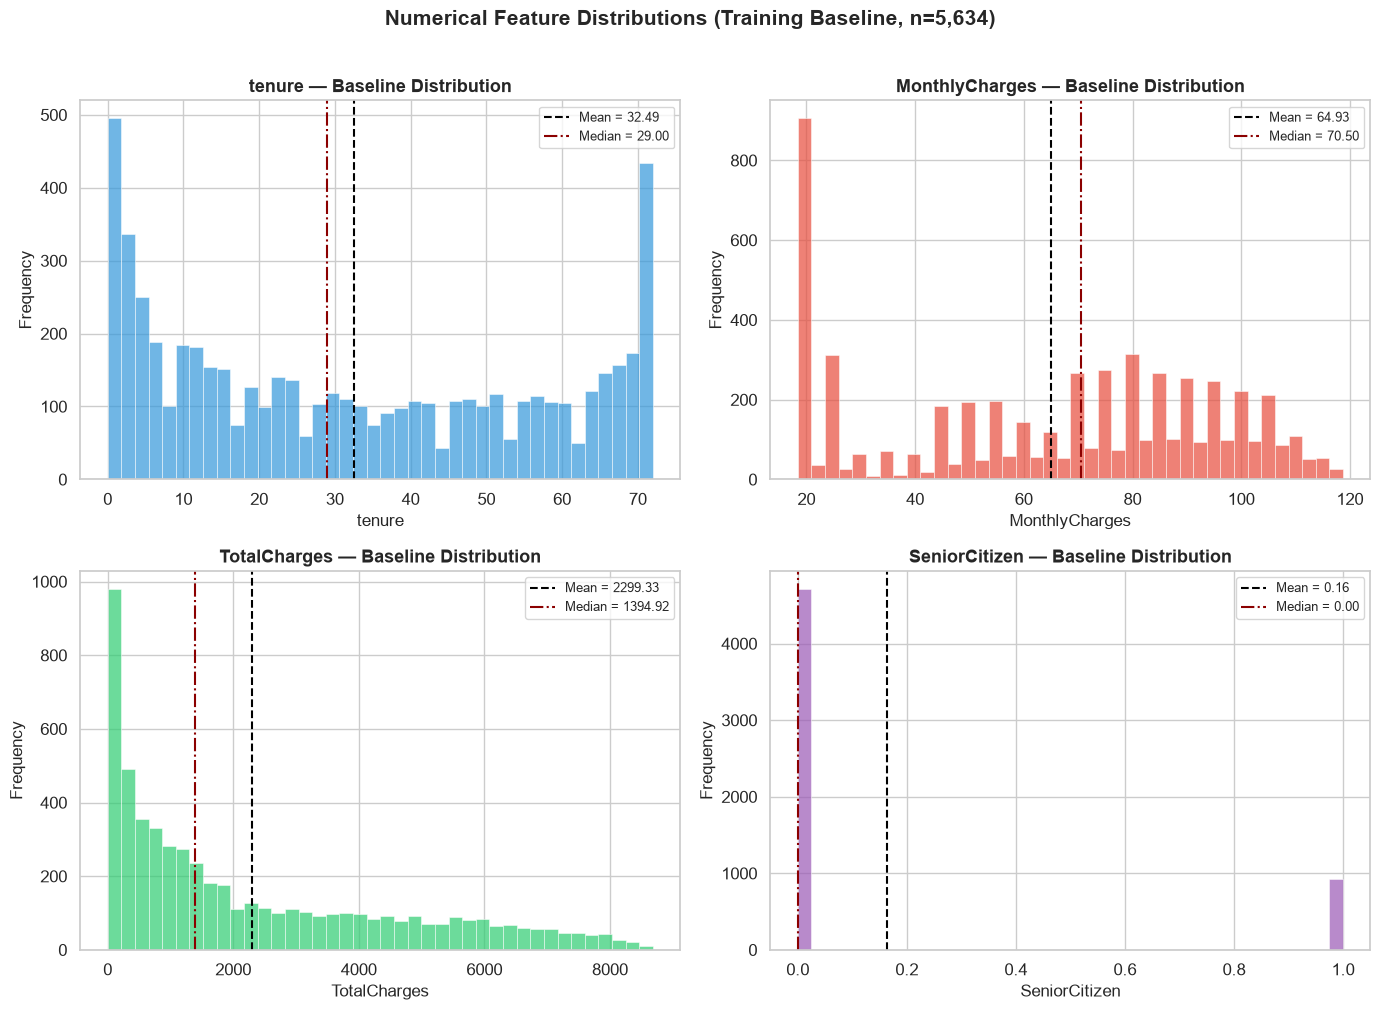

In [10]:
# ── Numerical distributions ────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

colors = ["#3498db", "#e74c3c", "#2ecc71", "#9b59b6"]

for i, feat in enumerate(NUMERICAL_FEATURES):
    ax = axes[i]
    data = baseline_df[feat].dropna()

    ax.hist(data, bins=40, color=colors[i], alpha=0.7, edgecolor="white", linewidth=0.5)
    ax.axvline(data.mean(), color="black", linestyle="--", linewidth=1.5, label=f"Mean = {data.mean():.2f}")
    ax.axvline(data.median(), color="darkred", linestyle="-.", linewidth=1.5, label=f"Median = {data.median():.2f}")
    ax.set_title(f"{feat} — Baseline Distribution", fontsize=13, fontweight="bold")
    ax.set_xlabel(feat)
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=9)

fig.suptitle("Numerical Feature Distributions (Training Baseline, n=5,634)", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### 7.2 Categorical Feature Distributions

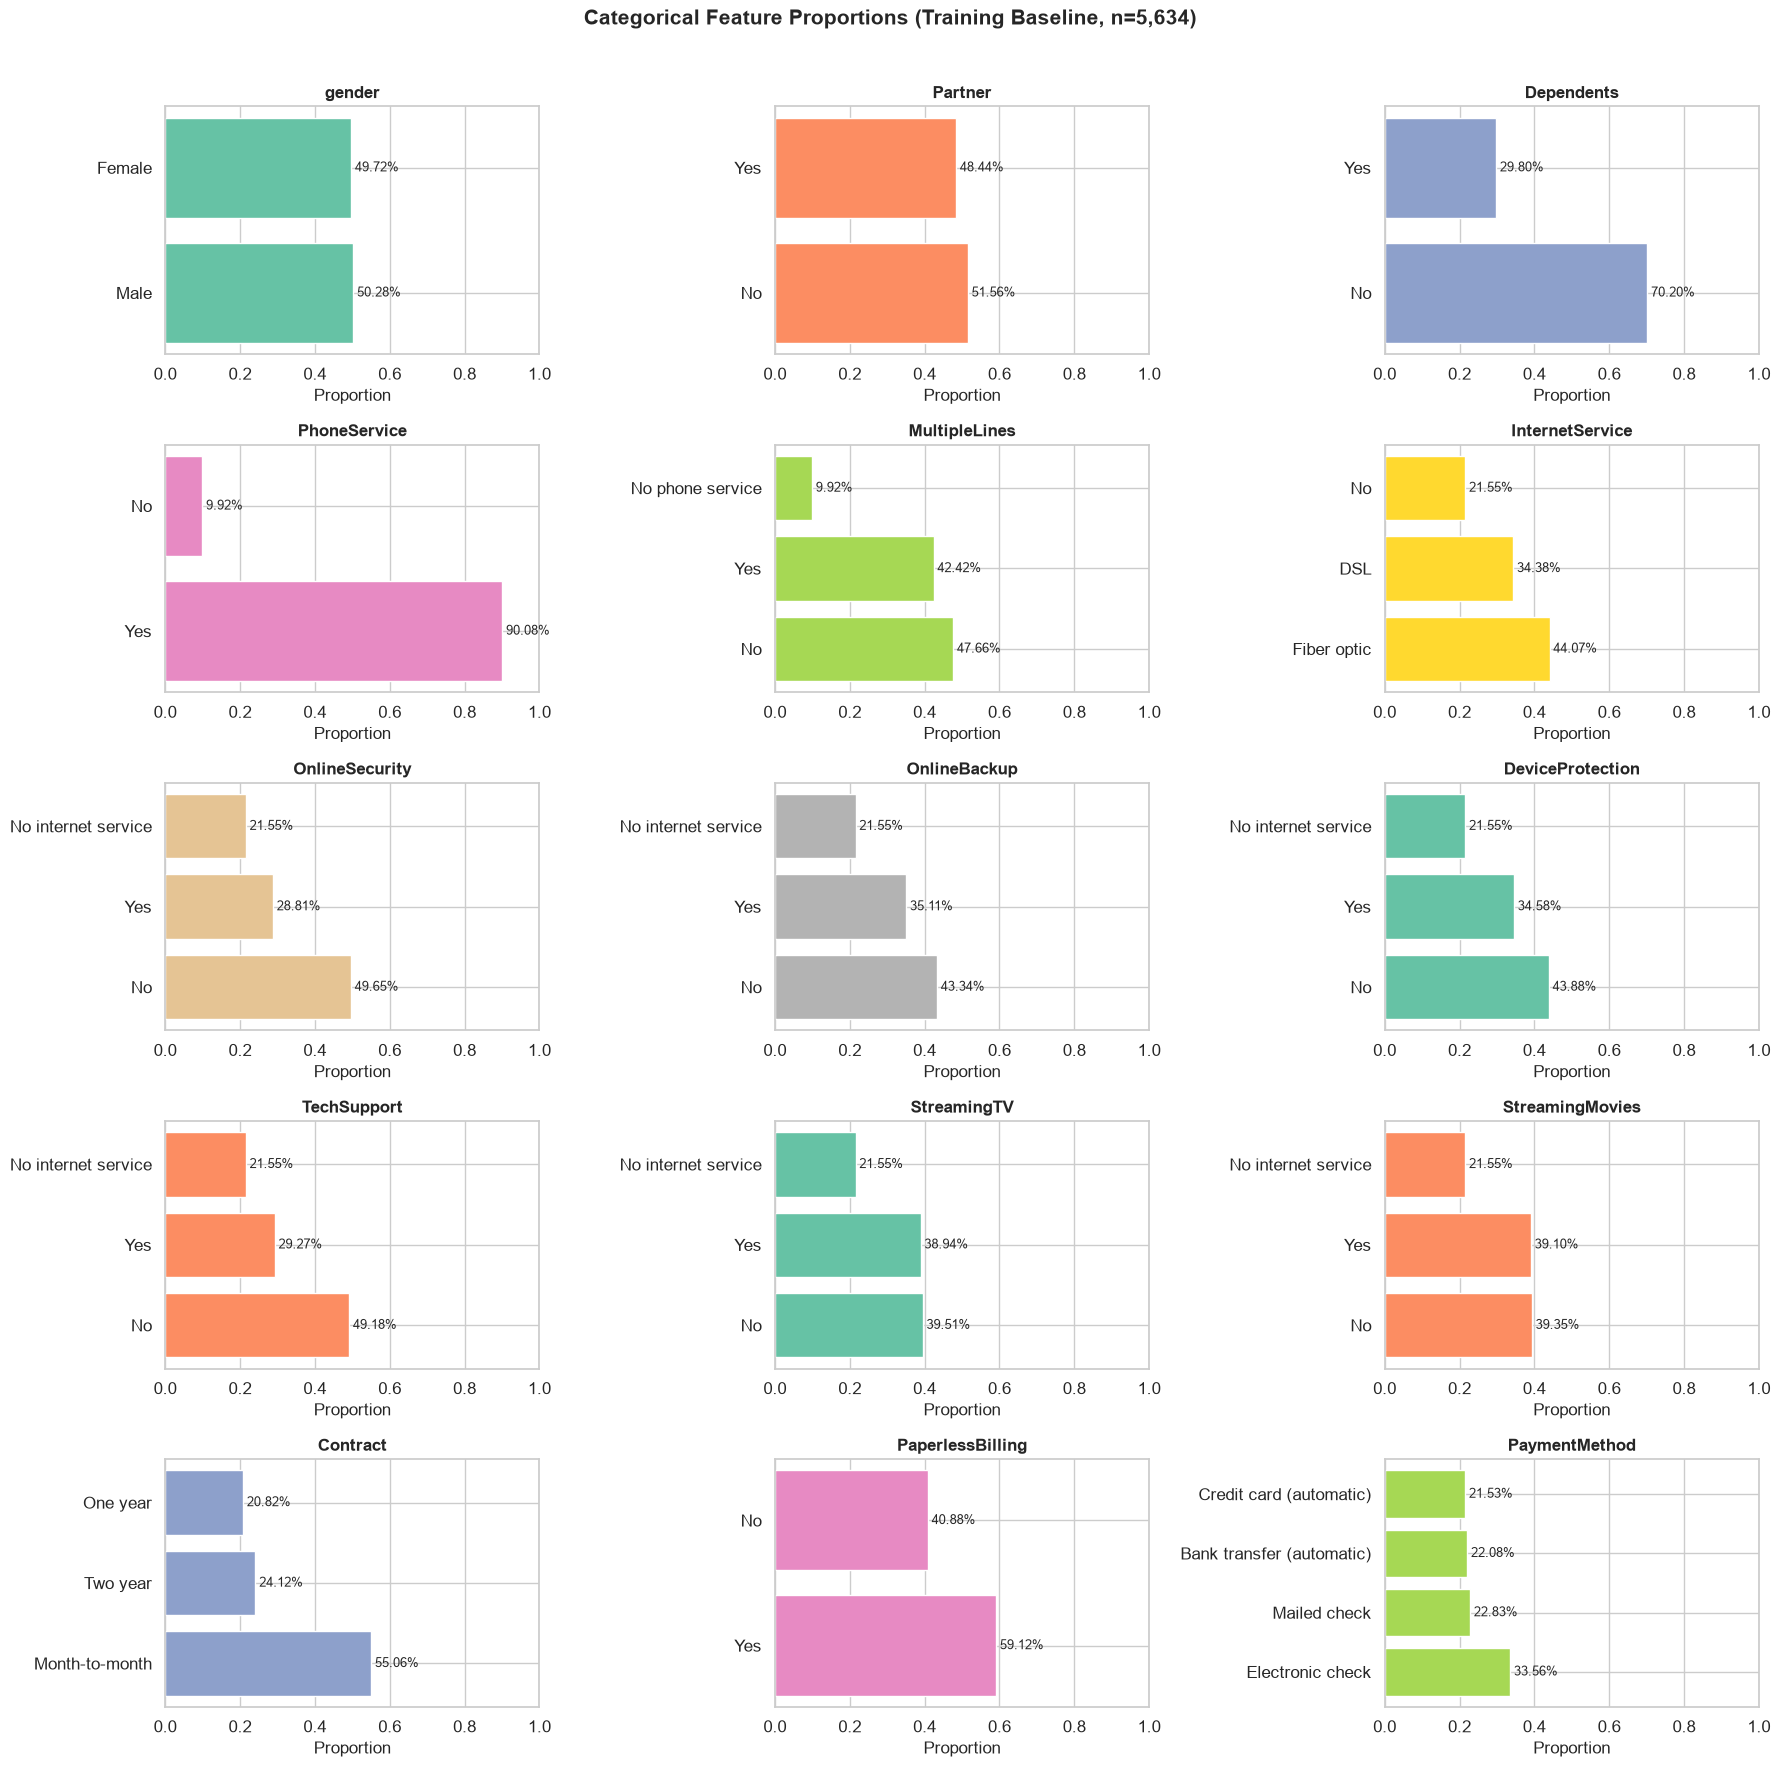

In [11]:
# ── Categorical distributions ──────────────────────────────────────────
n_cats = len(CATEGORICAL_FEATURES)
n_cols = 3
n_rows = (n_cats + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3.5))
axes = axes.ravel()

palette = sns.color_palette("Set2", 10)

for i, feat in enumerate(CATEGORICAL_FEATURES):
    ax = axes[i]
    props = cat_profile[feat]["proportions"]
    categories = list(props.keys())
    values = list(props.values())

    bars = ax.barh(categories, values, color=palette[i % len(palette)], edgecolor="white")
    ax.set_title(feat, fontsize=12, fontweight="bold")
    ax.set_xlim(0, 1.0)
    ax.set_xlabel("Proportion")

    for bar, val in zip(bars, values):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
                f"{val:.2%}", va="center", fontsize=9)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Categorical Feature Proportions (Training Baseline, n=5,634)",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

---
## 8. Save Baseline Profile

All baseline artifacts are saved to `artifacts/monitoring/`.
This directory is new for V7 and does not conflict with existing V1–V6 artifacts.

In [12]:
# ── Build the complete baseline profile ────────────────────────────────
baseline_profile = {
    "version": "V7.1",
    "created_at": datetime.now().isoformat(),
    "description": (
        "Baseline data profile for data-drift monitoring. "
        "Represents the statistical characteristics of the training data "
        "used to train the fixed baseline XGBoost model (V4) with threshold 0.29 (V5)."
    ),
    "dataset": {
        "source": "data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv",
        "total_dataset_rows": int(df.shape[0]),
        "baseline_rows": int(X_train.shape[0]),
        "baseline_source": "X_train (training split, 80%, random_state=42, stratify=y)",
        "target_column": TARGET_COL,
        "id_column": ID_COL,
        "target_excluded_from_drift": True,
    },
    "features": {
        "numerical": NUMERICAL_FEATURES,
        "categorical": CATEGORICAL_FEATURES,
        "total_monitored": len(NUMERICAL_FEATURES) + len(CATEGORICAL_FEATURES),
    },
    "numerical_profile": {feat: rec for feat, rec in zip(
        [r["feature"] for r in num_profile_records],
        [{k: v for k, v in r.items() if k != "feature"} for r in num_profile_records]
    )},
    "categorical_profile": cat_profile,
    "quality": quality_profile,
}

# ── Save complete profile (JSON) ──────────────────────────────────────
profile_path = MONITORING_DIR / "baseline_profile_v7.json"
with open(profile_path, "w") as f:
    json.dump(baseline_profile, f, indent=2, default=str)
print(f"✓ Complete baseline profile saved to: {profile_path}")

# ── Save numerical profile (CSV) ──────────────────────────────────────
num_csv_path = MONITORING_DIR / "baseline_numeric_profile_v7.csv"
num_profile_df.reset_index().to_csv(num_csv_path, index=False)
print(f"✓ Numerical profile saved to: {num_csv_path}")

# ── Save categorical summary (CSV) ────────────────────────────────────
cat_csv_path = MONITORING_DIR / "baseline_categorical_profile_v7.csv"
cat_summary_df.reset_index().to_csv(cat_csv_path, index=False)
print(f"✓ Categorical profile saved to: {cat_csv_path}")

# ── Save quality profile (JSON) ───────────────────────────────────────
quality_path = MONITORING_DIR / "baseline_quality_profile_v7.json"
with open(quality_path, "w") as f:
    json.dump(quality_profile, f, indent=2, default=str)
print(f"✓ Quality profile saved to: {quality_path}")

print("\nAll V7.1 baseline artifacts saved successfully. ✓")

✓ Complete baseline profile saved to: /Users/shubhamswaraj/Desktop/PLACEMENT/IntelliPulse/artifacts/monitoring/baseline_profile_v7.json
✓ Numerical profile saved to: /Users/shubhamswaraj/Desktop/PLACEMENT/IntelliPulse/artifacts/monitoring/baseline_numeric_profile_v7.csv
✓ Categorical profile saved to: /Users/shubhamswaraj/Desktop/PLACEMENT/IntelliPulse/artifacts/monitoring/baseline_categorical_profile_v7.csv
✓ Quality profile saved to: /Users/shubhamswaraj/Desktop/PLACEMENT/IntelliPulse/artifacts/monitoring/baseline_quality_profile_v7.json

All V7.1 baseline artifacts saved successfully. ✓


---
## 9. Validation

Sanity checks to confirm the baseline profile is correct and complete.

In [13]:
# ── Sanity checks ─────────────────────────────────────────────────────
print("V7.1 BASELINE VALIDATION")
print("=" * 70)

checks_passed = 0
checks_total = 0

# Check 1: Row count matches training data
checks_total += 1
expected_rows = 5634
actual_rows = baseline_df.shape[0]
if actual_rows == expected_rows:
    print(f"  [PASS] Baseline row count: {actual_rows} == {expected_rows}")
    checks_passed += 1
else:
    print(f"  [FAIL] Baseline row count: {actual_rows} != {expected_rows}")

# Check 2: Target excluded
checks_total += 1
if TARGET_COL not in baseline_df.columns:
    print(f"  [PASS] Target column '{TARGET_COL}' excluded from drift features")
    checks_passed += 1
else:
    print(f"  [FAIL] Target column '{TARGET_COL}' found in drift features!")

# Check 3: Numerical statistics match
checks_total += 1
tenure_mean_direct = round(float(X_train["tenure"].mean()), 4)
tenure_mean_profile = num_profile_records[0]["mean"]
if abs(tenure_mean_direct - tenure_mean_profile) < 0.001:
    print(f"  [PASS] tenure mean matches: direct={tenure_mean_direct}, profile={tenure_mean_profile}")
    checks_passed += 1
else:
    print(f"  [FAIL] tenure mean mismatch: direct={tenure_mean_direct}, profile={tenure_mean_profile}")

# Check 4: Categorical proportions sum to ~1
checks_total += 1
prop_check_pass = True
for feat in CATEGORICAL_FEATURES:
    prop_sum = sum(cat_profile[feat]["proportions"].values())
    if abs(prop_sum - 1.0) > 0.01:
        print(f"  [FAIL] {feat} proportions sum to {prop_sum:.4f} (expected ~1.0)")
        prop_check_pass = False
if prop_check_pass:
    print(f"  [PASS] All categorical proportions sum to ~1.0")
    checks_passed += 1

# Check 5: No unexpected feature loss
checks_total += 1
expected_features = len(NUMERICAL_FEATURES) + len(CATEGORICAL_FEATURES)
actual_features = len(num_present) + len(cat_present)
if actual_features == expected_features:
    print(f"  [PASS] All {expected_features} features present (4 numerical + 15 categorical)")
    checks_passed += 1
else:
    print(f"  [FAIL] Feature count mismatch: {actual_features} vs expected {expected_features}")

# Check 6: Saved profile loads back successfully
checks_total += 1
try:
    with open(profile_path) as f:
        loaded_profile = json.load(f)
    loaded_num_csv = pd.read_csv(num_csv_path)
    loaded_cat_csv = pd.read_csv(cat_csv_path)
    with open(quality_path) as f:
        loaded_quality = json.load(f)

    # Verify key values round-trip correctly
    assert loaded_profile["dataset"]["baseline_rows"] == expected_rows
    assert loaded_profile["features"]["total_monitored"] == expected_features
    assert len(loaded_num_csv) == len(NUMERICAL_FEATURES)
    assert len(loaded_cat_csv) == len(CATEGORICAL_FEATURES)
    assert loaded_quality["total_rows"] == expected_rows

    print(f"  [PASS] All saved artifacts load back successfully and values match")
    checks_passed += 1
except Exception as e:
    print(f"  [FAIL] Error loading saved artifacts: {e}")

print()
print("=" * 70)
print(f"  RESULT: {checks_passed}/{checks_total} checks passed")
if checks_passed == checks_total:
    print("  STATUS: ALL VALIDATIONS PASSED ✓")
else:
    print(f"  STATUS: {checks_total - checks_passed} CHECK(S) FAILED ✗")
print("=" * 70)

V7.1 BASELINE VALIDATION
  [PASS] Baseline row count: 5634 == 5634
  [PASS] Target column 'Churn' excluded from drift features
  [PASS] tenure mean matches: direct=32.4851, profile=32.4851
  [PASS] All categorical proportions sum to ~1.0
  [PASS] All 19 features present (4 numerical + 15 categorical)
  [PASS] All saved artifacts load back successfully and values match

  RESULT: 6/6 checks passed
  STATUS: ALL VALIDATIONS PASSED ✓


---
## 10. Data-Drift Monitoring Concept

### What is the Baseline Profile?

> *The baseline profile represents the statistical characteristics of the data
> distribution used to train the fixed baseline model.*

The tuned XGBoost model (V4) with threshold 0.29 (V5) was trained on data with
specific distributional properties — for example, a certain percentage of customers
on month-to-month contracts, a certain average tenure, etc.

If future incoming data batches have **significantly different** distributions,
the model's predictions may become unreliable — even if the model code and weights
are unchanged.

### How Will Drift Be Detected?

Future incoming batches will be compared against this baseline profile.

**Example:**

```
BASELINE (Training Data)            NEW BATCH (Incoming Data)
─────────────────────────           ─────────────────────────
Contract:                           Contract:
  Month-to-month = 55%               Month-to-month = 78%
  One year       = 21%               One year       = 12%
  Two year       = 24%               Two year       = 10%

tenure:                             tenure:
  mean = ~32 months                   mean = ~12 months
  std  = ~24 months                   std  = ~8 months
```

The monitoring engine will determine whether these differences are
**statistically meaningful** using appropriate tests (e.g., KS test for numerical
features, chi-squared test for categorical features).

> ⚠️ **Important:** The values above are illustrative. The 78% month-to-month figure
> is a hypothetical example — no actual drift has been calculated, and no real
> incoming batch has been generated yet. Actual drift detection will occur in a
> later V7 stage.

---
## 11. Final V7.1 Findings

In [14]:
# ── Final summary ─────────────────────────────────────────────────────
print("=" * 80)
print("  IntelliPulse V7.1 — Baseline Data Profile Findings")
print("=" * 80)
print()

print(f"1. Number of rows in baseline      : {baseline_df.shape[0]:,}")
print(f"2. Number of monitored features    : {len(NUMERICAL_FEATURES) + len(CATEGORICAL_FEATURES)}")
print(f"3. Numerical features ({len(NUMERICAL_FEATURES)})          : {NUMERICAL_FEATURES}")
print(f"4. Categorical features ({len(CATEGORICAL_FEATURES)})       : {CATEGORICAL_FEATURES}")
print()

print("5. Important baseline distributions:")
print("-" * 60)
for feat in NUMERICAL_FEATURES:
    col = baseline_df[feat]
    print(f"   {feat:20s}: mean={col.mean():.2f}, median={col.median():.2f}, std={col.std():.2f}")
print()
for feat in ["Contract", "InternetService", "PaymentMethod"]:
    print(f"   {feat}:")
    for cat, prop in sorted(cat_profile[feat]["proportions"].items(), key=lambda x: -x[1]):
        print(f"     {cat:30s}: {prop:.2%}")
print()

print(f"6. Baseline data-quality issues    : ", end="")
if duplicate_rows == 0 and total_missing == 0:
    print("None detected (0 duplicates, 0 missing values)")
else:
    issues = []
    if duplicate_rows > 0:
        issues.append(f"{duplicate_rows} duplicate rows")
    if total_missing > 0:
        issues.append(f"{total_missing} missing values")
    print(", ".join(issues))
print()

print("7. Saved baseline artifacts:")
print(f"   • {MONITORING_DIR / 'baseline_profile_v7.json'}")
print(f"   • {MONITORING_DIR / 'baseline_numeric_profile_v7.csv'}")
print(f"   • {MONITORING_DIR / 'baseline_categorical_profile_v7.csv'}")
print(f"   • {MONITORING_DIR / 'baseline_quality_profile_v7.json'}")
print()
print("=" * 80)
print()
print("V7.1 establishes the reference distribution required for future")
print("data-drift monitoring.")
print()
print("=" * 80)

  IntelliPulse V7.1 — Baseline Data Profile Findings

1. Number of rows in baseline      : 5,634
2. Number of monitored features    : 19
3. Numerical features (4)          : ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']
4. Categorical features (15)       : ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

5. Important baseline distributions:
------------------------------------------------------------
   tenure              : mean=32.49, median=29.00, std=24.57
   MonthlyCharges      : mean=64.93, median=70.50, std=30.14
   TotalCharges        : mean=2299.33, median=1394.92, std=2279.20
   SeniorCitizen       : mean=0.16, median=0.00, std=0.37

   Contract:
     Month-to-month                : 55.06%
     Two year                      : 24.12%
     One year                      : 20